In [1]:
# ====================================================================
# PHASE 1: DATA INGESTION & STRUCTURAL INTEGRITY INSPECTION
# ====================================================================

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Ingest the IBM Telco Churn database

In [4]:
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [5]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [6]:
# Verify baseline structural shape, column data types, and check for null fields

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
# ====================================================================
# PHASE 2: UPSTREAM DATA CLEANING & SCHEMATIC CORRECTION
# ====================================================================

In [12]:
# Ensure strict data types: Convert TotalCharges from object to numeric, coercion handling for empty spaces

In [13]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [14]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [16]:
df[df["TotalCharges"].isna()][['tenure','Contract','PaymentMethod']]

,tenure,Contract,PaymentMethod
488,0,Two year,Bank transfer (automatic)
753,0,Two year,Mailed check
936,0,Two year,Mailed check
1082,0,Two year,Mailed check
1340,0,Two year,Credit card (automatic)
3331,0,Two year,Mailed check
3826,0,Two year,Mailed check
4380,0,Two year,Mailed check
5218,0,One year,Mailed check
6670,0,Two year,Mailed check


In [17]:
df[df["tenure"]==0].count()

customerID          11
gender              11
SeniorCitizen       11
Partner             11
Dependents          11
tenure              11
PhoneService        11
MultipleLines       11
InternetService     11
OnlineSecurity      11
OnlineBackup        11
DeviceProtection    11
TechSupport         11
StreamingTV         11
StreamingMovies     11
Contract            11
PaperlessBilling    11
PaymentMethod       11
MonthlyCharges      11
TotalCharges         0
Churn               11
dtype: int64

In [18]:
# BUSINESS LOGIC: New customers (tenure=0) generated Nulls during coercion.
# We fill their TotalCharges using MonthlyCharges to preserve their records instead of dropping them

In [19]:
df["TotalCharges"]=df["TotalCharges"].fillna(df["MonthlyCharges"])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [21]:
#====================================================================
# PHASE 3: Track value distributions for core contract attributes and target metrics
# ====================================================================

In [22]:
df["Churn"].value_counts()

No     5174
Yes    1869
Name: Churn, dtype: int64

<AxesSubplot:xlabel='TotalCharges', ylabel='Count'>

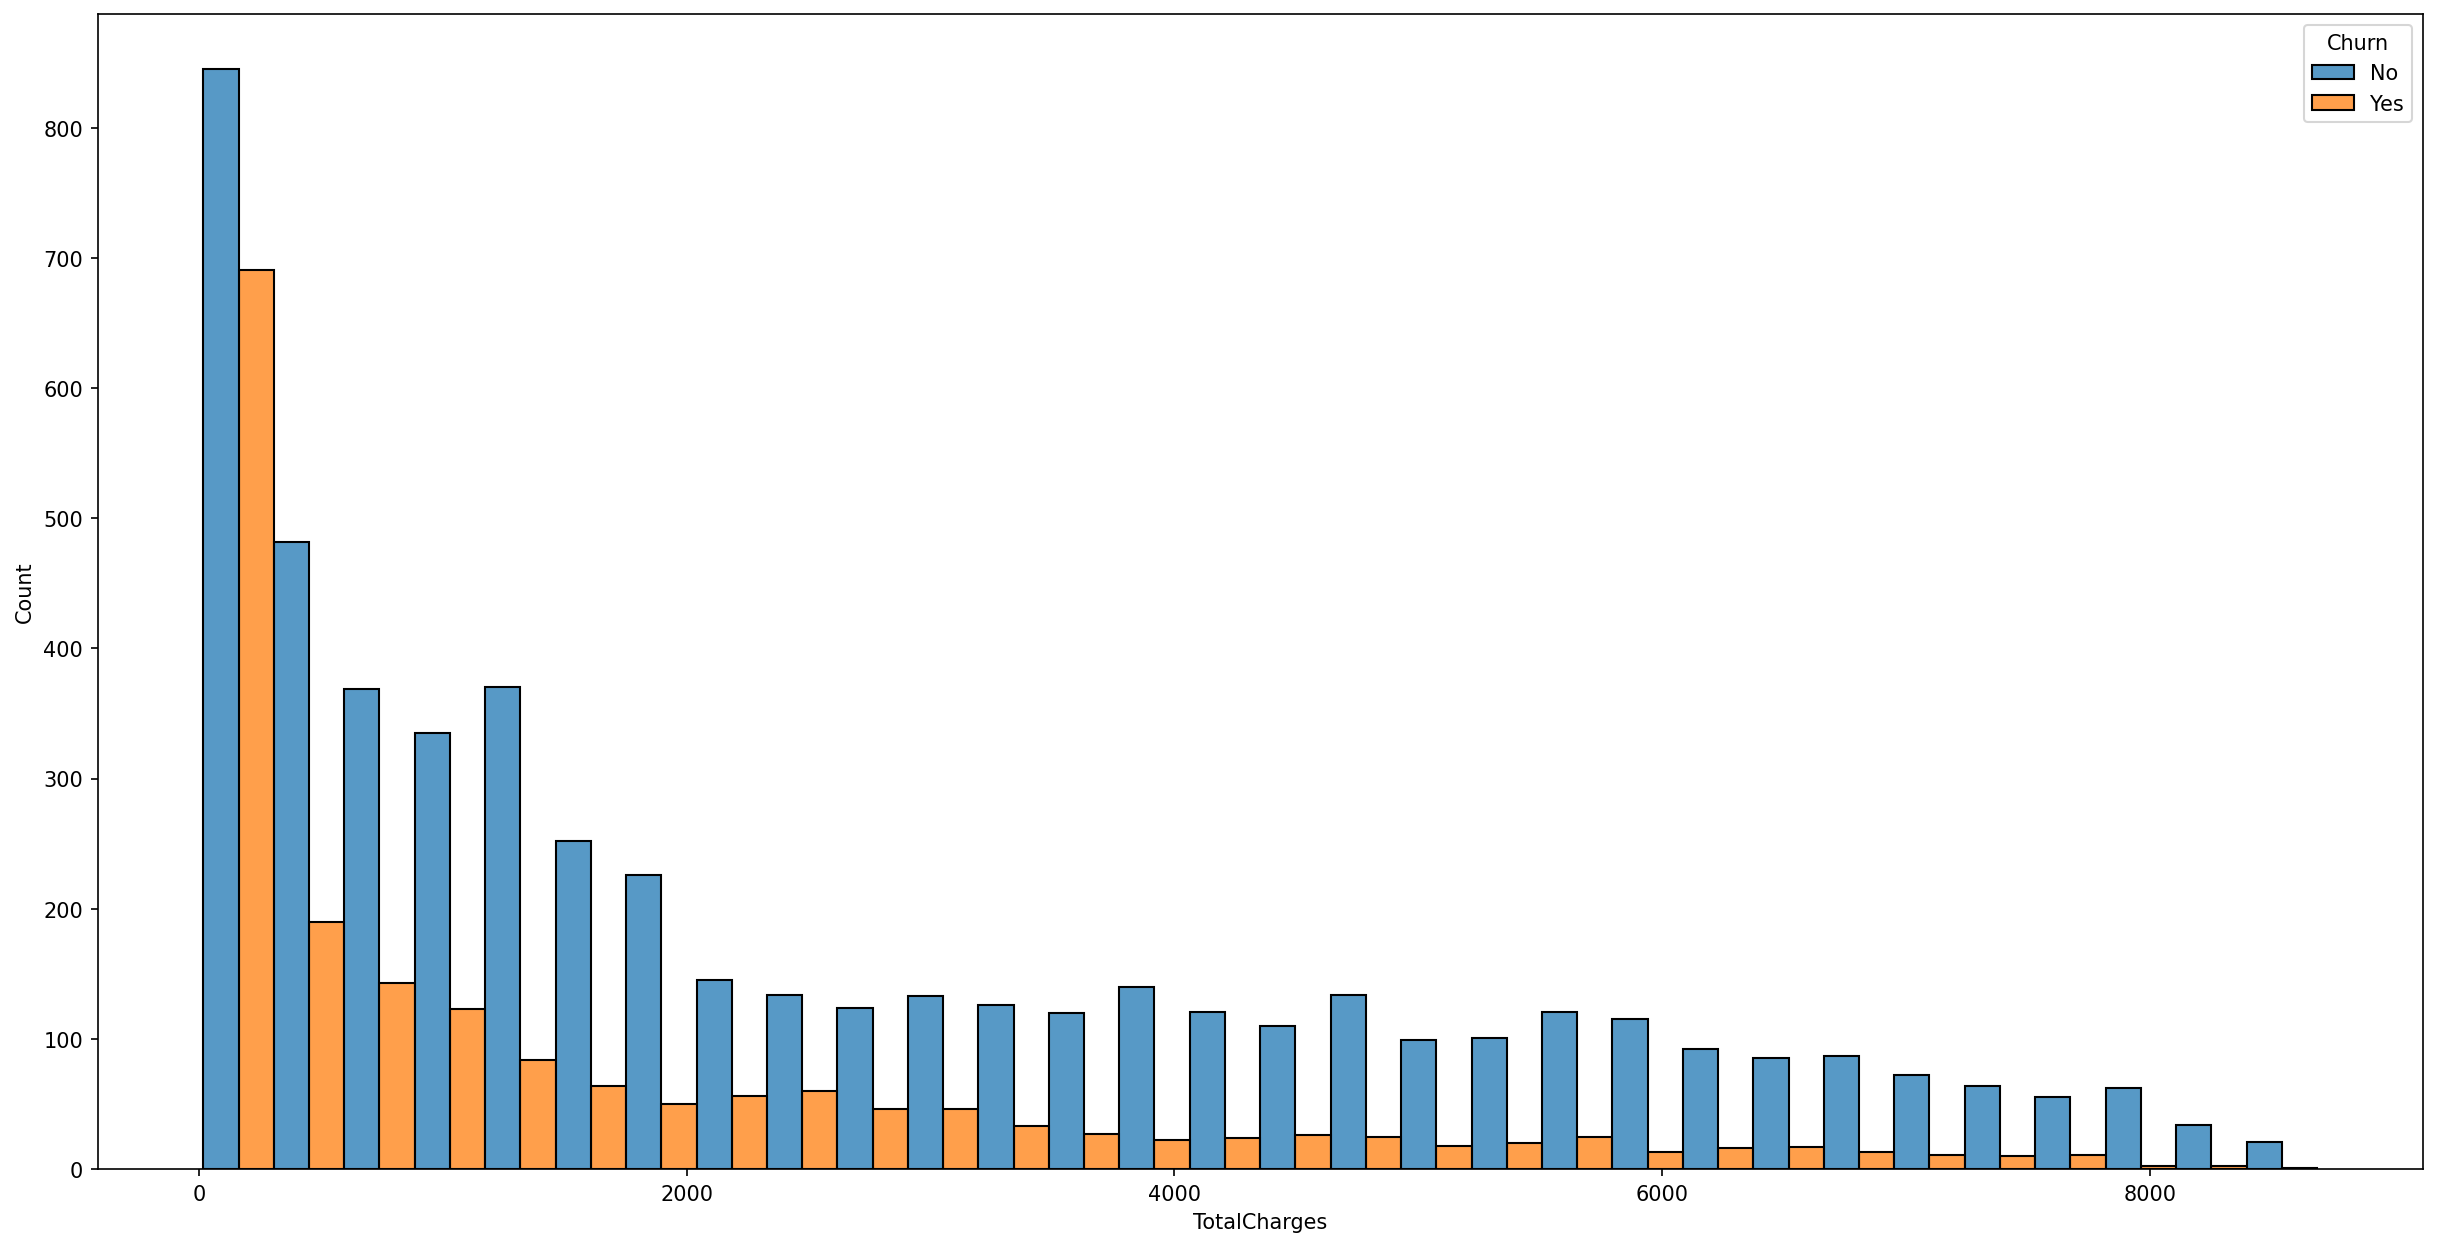

In [23]:
plt.figure(figsize=(20,10),dpi=150)
sns.histplot(data=df,x="TotalCharges",bins=30,hue='Churn',multiple="dodge")

<AxesSubplot:xlabel='MonthlyCharges', ylabel='Count'>

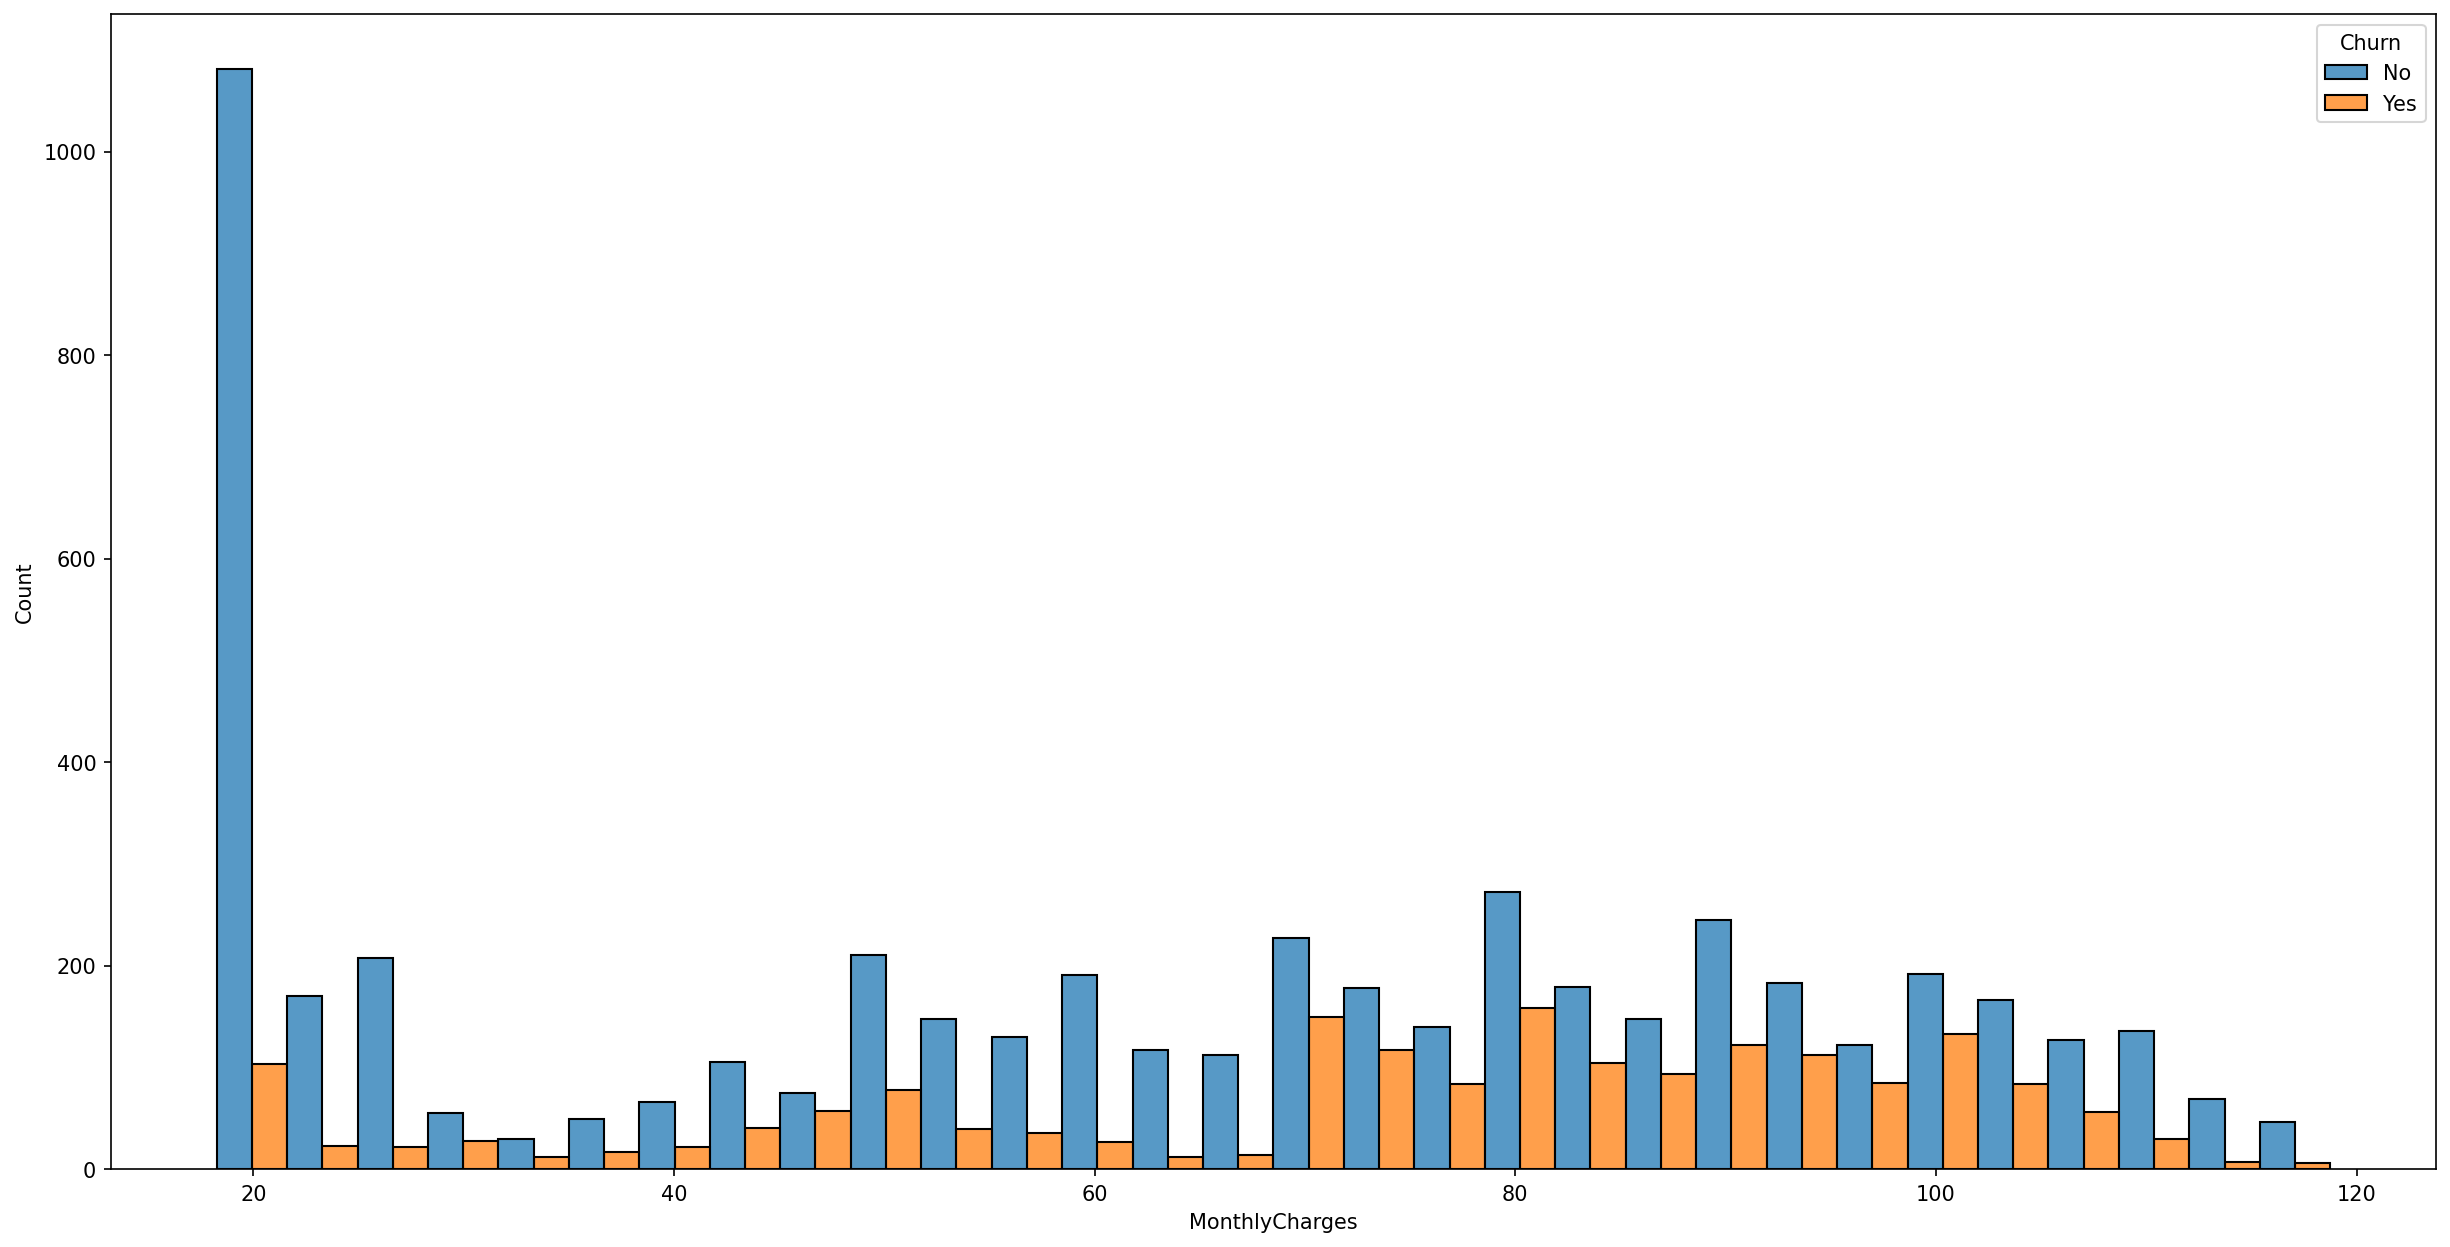

In [24]:
plt.figure(figsize=(20,10),dpi=150)
sns.histplot(data=df,x="MonthlyCharges",bins=30,hue='Churn',multiple="dodge")

In [25]:
df["PaymentMethod"].value_counts()

Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: PaymentMethod, dtype: int64

In [26]:
df.groupby('Churn')['MonthlyCharges'].describe().transpose()

Churn,No,Yes
count,5174.000000,1869.000000
mean,61.265124,74.441332
std,31.092648,24.666053
min,18.250000,18.850000
25%,25.100000,56.150000
50%,64.425000,79.650000
75%,88.400000,94.200000
max,118.750000,118.350000


In [27]:
df.groupby('Churn')['TotalCharges'].describe().transpose()

Churn,No,Yes
count,5174.000000,1869.000000
mean,2549.999497,1531.796094
std,2329.858843,1890.822994
min,18.800000,18.850000
25%,572.900000,134.500000
50%,1679.525000,703.550000
75%,4262.850000,2331.300000
max,8672.450000,8684.800000


In [28]:
df["Contract"].value_counts()

Month-to-month    3875
Two year          1695
One year          1473
Name: Contract, dtype: int64

<AxesSubplot:xlabel='Contract', ylabel='count'>

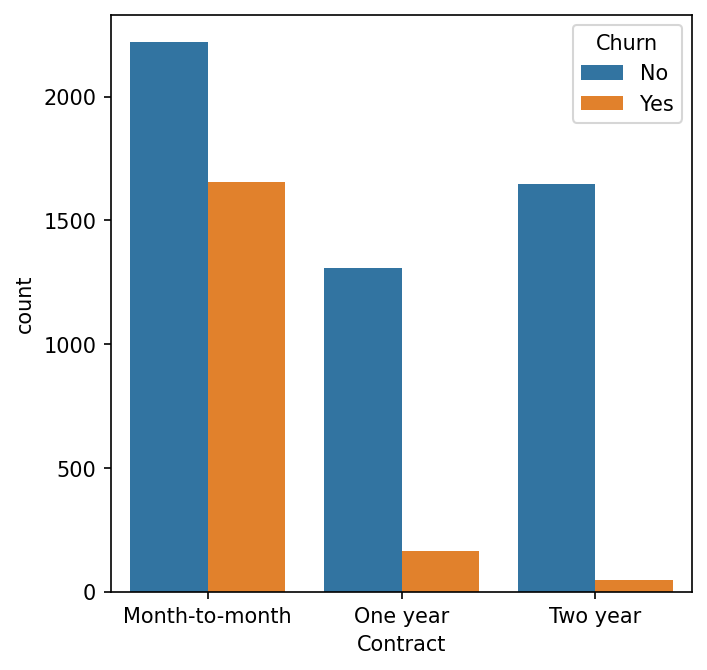

In [29]:
plt.figure(figsize=(5,5),dpi=150)
sns.countplot(data=df,x="Contract",hue="Churn")

<AxesSubplot:xlabel='Churn', ylabel='MonthlyCharges'>

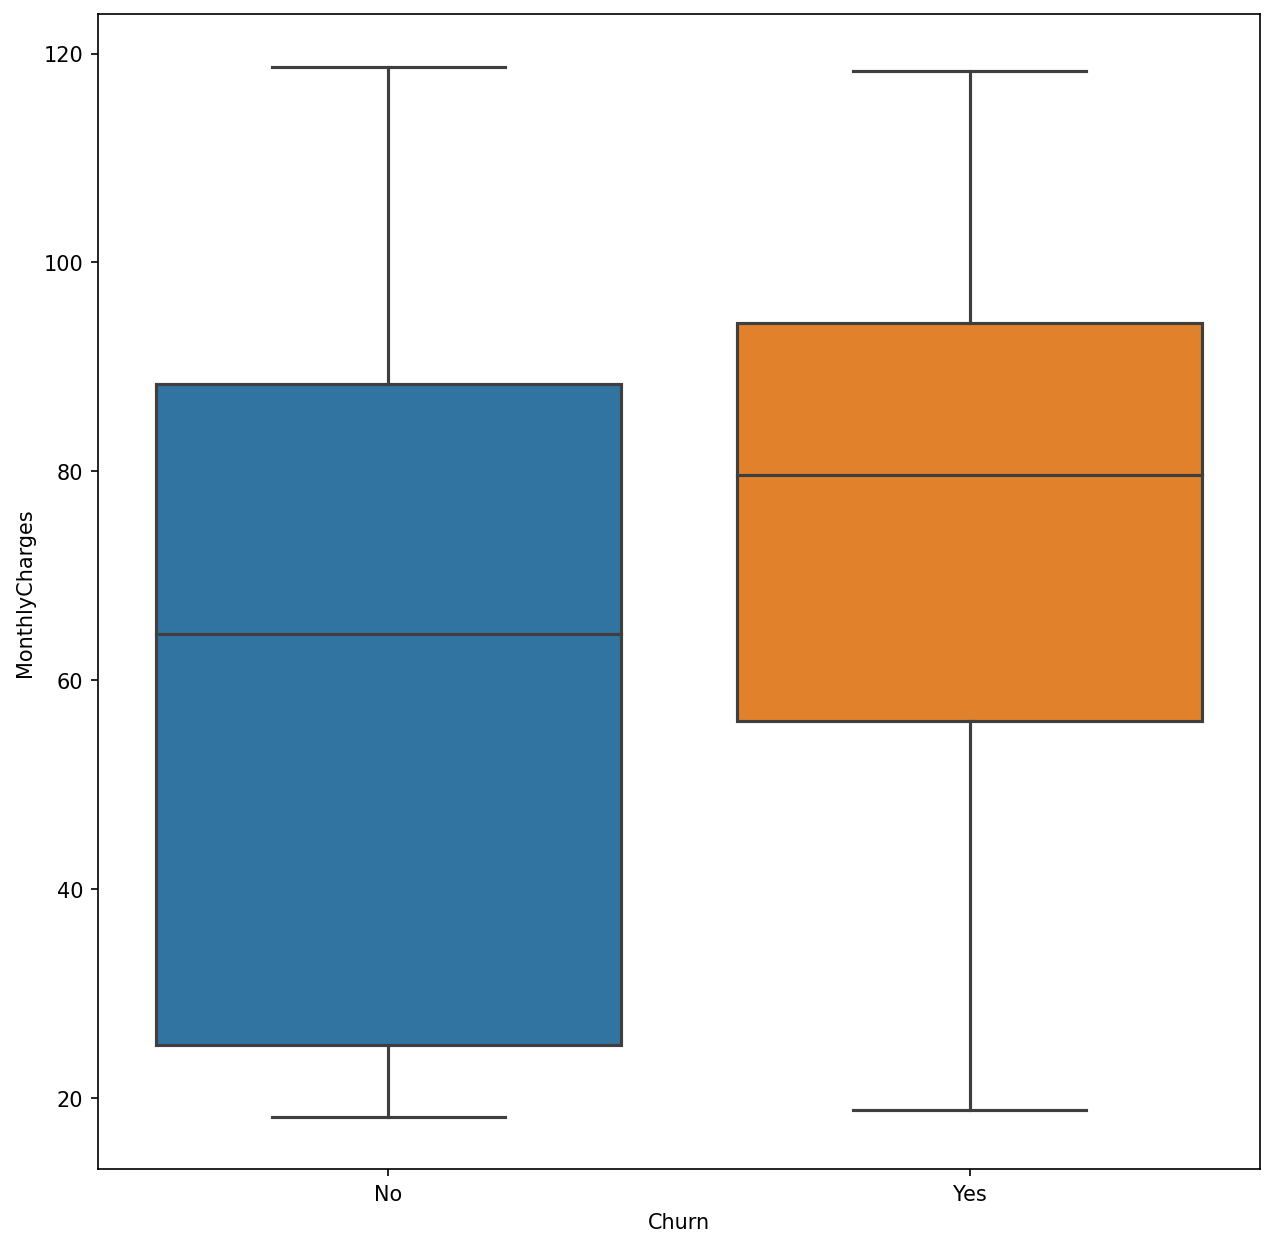

In [30]:
plt.figure(figsize=(10,10),dpi=150)
sns.boxplot(data=df,x="Churn",y="MonthlyCharges")

<AxesSubplot:xlabel='InternetService', ylabel='count'>

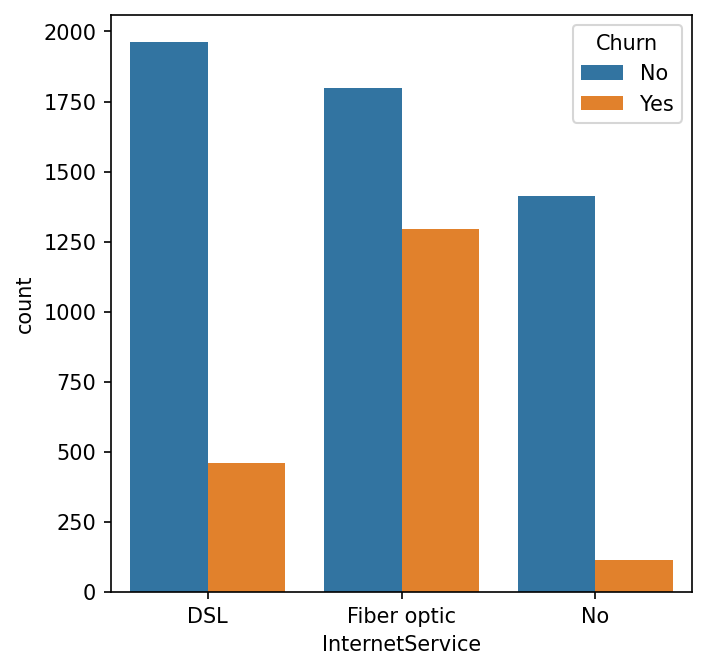

In [31]:
plt.figure(figsize=(5,5),dpi=150)
sns.countplot(data=df,x="InternetService",hue="Churn")

<AxesSubplot:xlabel='InternetService', ylabel='count'>

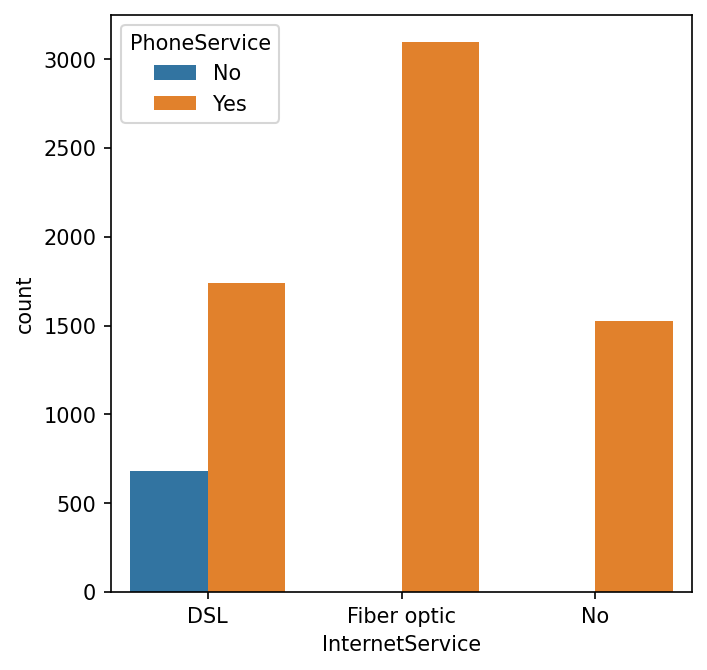

In [32]:
plt.figure(figsize=(5,5),dpi=150)
sns.countplot(data=df,x="InternetService",hue="PhoneService")

<AxesSubplot:xlabel='PhoneService', ylabel='count'>

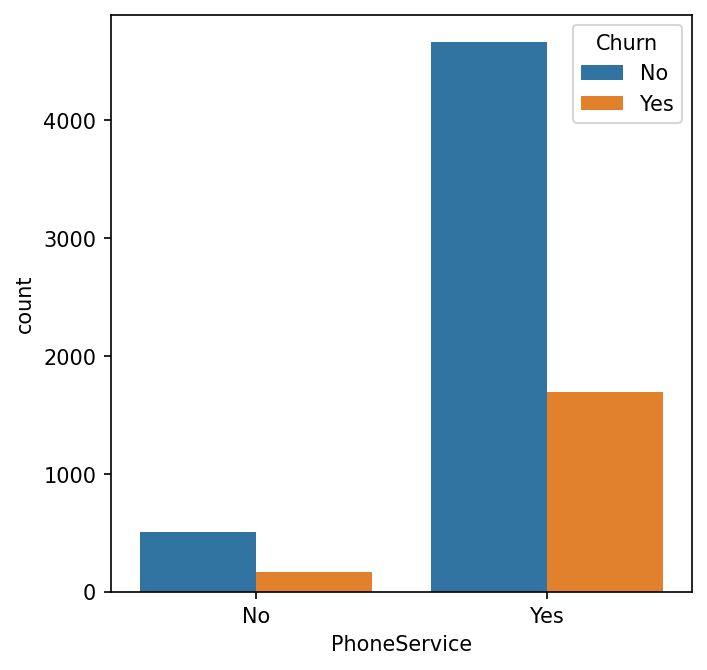

In [33]:
plt.figure(figsize=(5,5),dpi=150)
sns.countplot(data=df,x="PhoneService",hue="Churn")

In [34]:
#====================================================================
# PHASE 4: HIGHER-RISK COHORT SEGMENTATION & BEHAVIORAL ATTRIBUTES
# ====================================================================

In [35]:
ChurnY=df[df["Churn"]=="Yes"]

In [36]:
ChurnY

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7021,1699-HPSBG,Male,0,No,No,12,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Electronic check,59.80,727.80,Yes
7026,8775-CEBBJ,Female,0,No,No,9,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,Yes
7032,6894-LFHLY,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,75.75,75.75,Yes
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes


<AxesSubplot:xlabel='Contract', ylabel='count'>

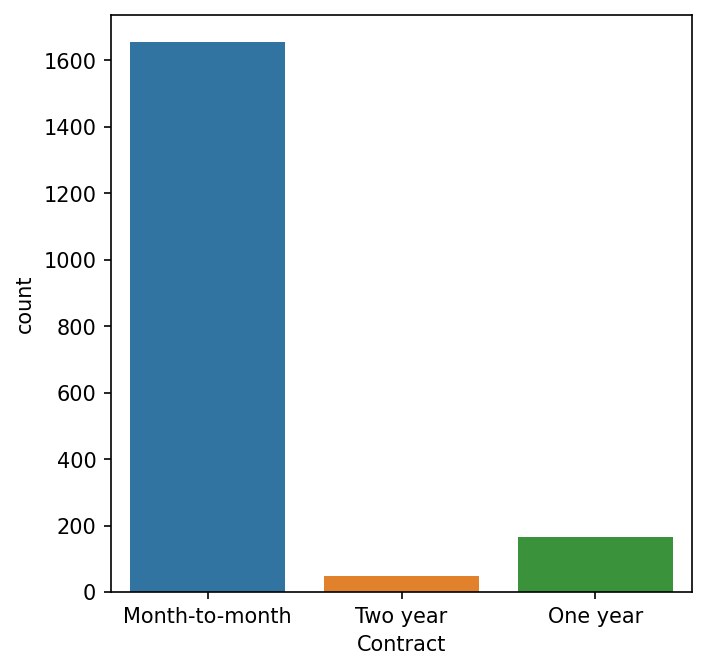

In [37]:
plt.figure(figsize=(5,5),dpi=150)
sns.countplot(data=ChurnY,x="Contract")

<AxesSubplot:xlabel='SeniorCitizen', ylabel='count'>

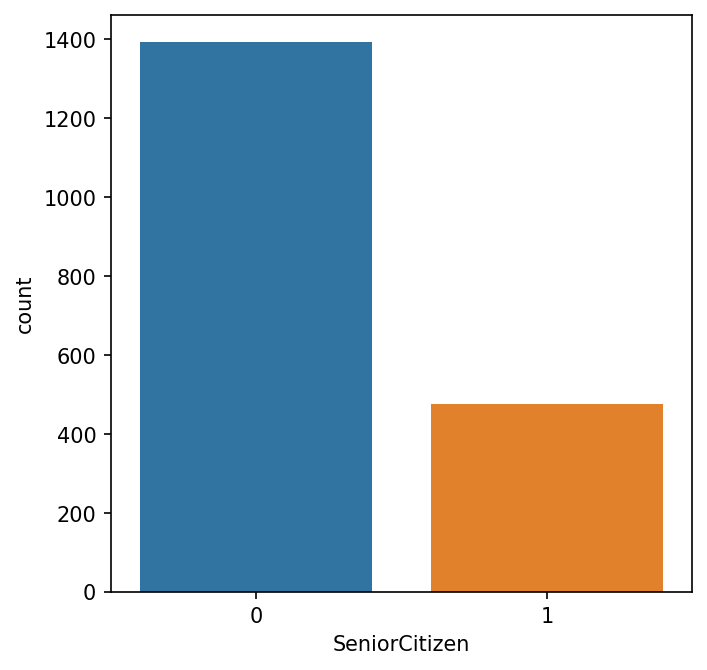

In [38]:
plt.figure(figsize=(5,5),dpi=150)
sns.countplot(data=ChurnY,x="SeniorCitizen")

<AxesSubplot:xlabel='TotalCharges', ylabel='Count'>

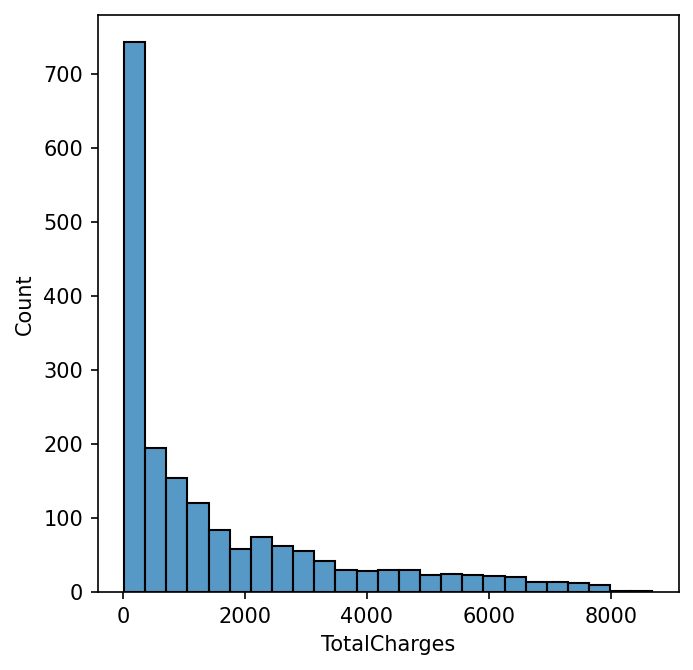

In [39]:
plt.figure(figsize=(5,5),dpi=150)
sns.histplot(data=ChurnY,x="TotalCharges")

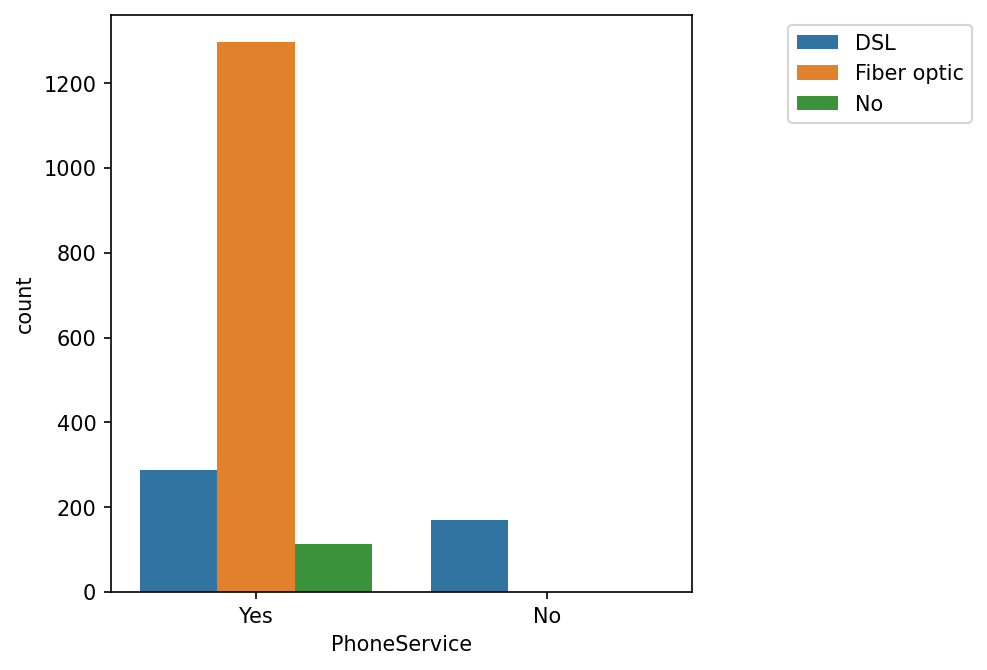

In [40]:
plt.figure(figsize=(5,5),dpi=150)
sns.countplot(data=ChurnY,x="PhoneService",hue="InternetService")
plt.legend(bbox_to_anchor=(1.5,1))

<AxesSubplot:xlabel='MonthlyCharges', ylabel='Count'>

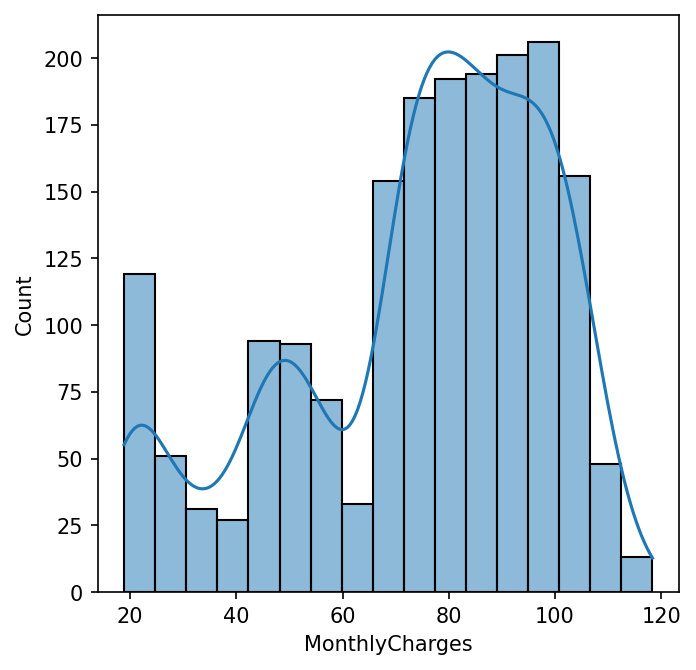

In [41]:
plt.figure(figsize=(5,5),dpi=150)
sns.histplot(data=ChurnY,x="MonthlyCharges",kde=True)

In [42]:
# Isolate high-risk pricing segments ($70 - $110) to audit pricing friction zones

In [43]:
high_charge_cohort = df[(df["MonthlyCharges"] >= 70) & (df["MonthlyCharges"] <= 110)]

In [44]:
high_charge_cohort["Contract"].value_counts()

Month-to-month    2079
One year           668
Two year           629
Name: Contract, dtype: int64

In [45]:
high_charge_cohort["PaymentMethod"].value_counts()

Electronic check             1566
Bank transfer (automatic)     750
Credit card (automatic)       735
Mailed check                  325
Name: PaymentMethod, dtype: int64

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Mailed check'),
  Text(1, 0, 'Electronic check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

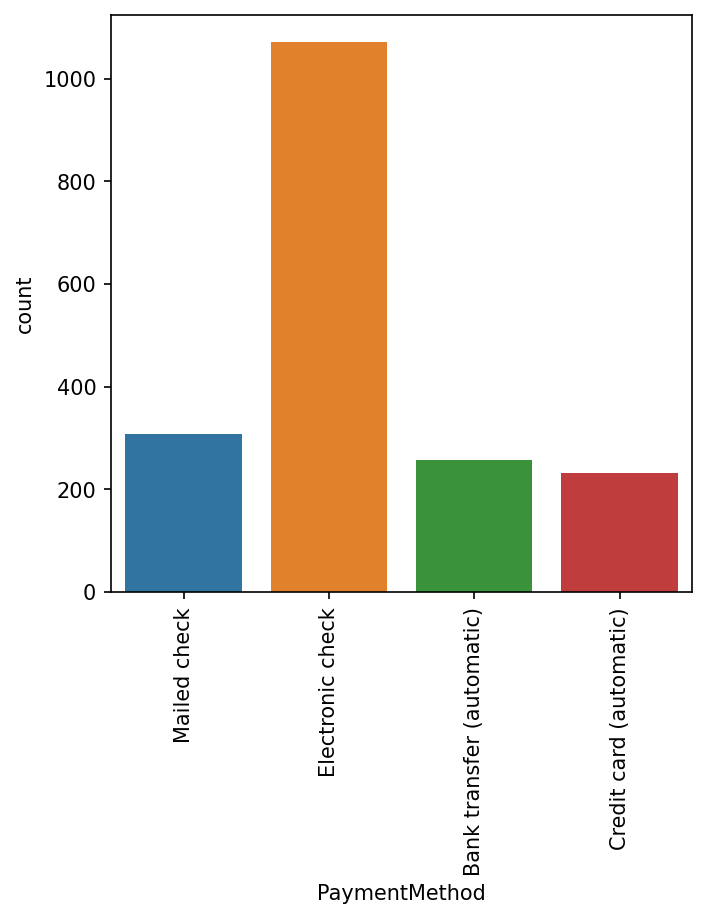

In [46]:
plt.figure(figsize=(5,5),dpi=150)
sns.countplot(data=ChurnY,x="PaymentMethod")
plt.xticks(rotation=90)

<AxesSubplot:xlabel='Contract', ylabel='Count'>

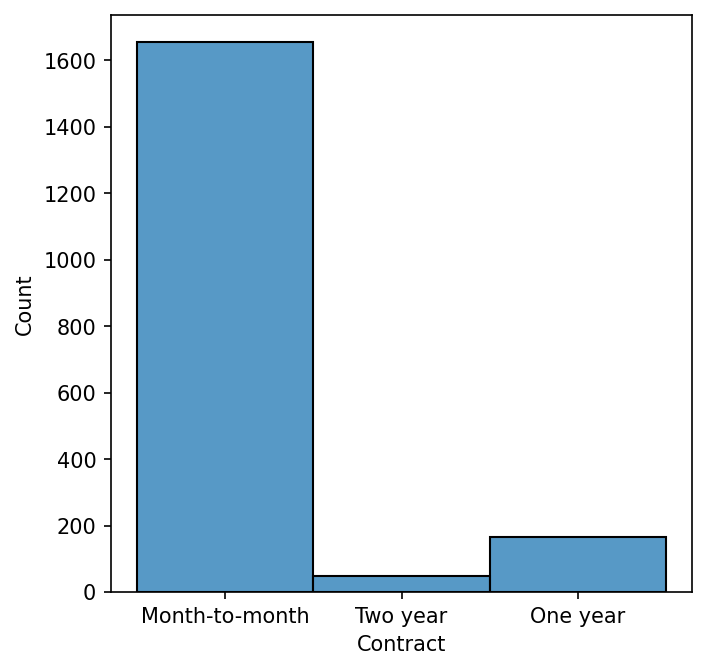

In [47]:
plt.figure(figsize=(5,5),dpi=150)
sns.histplot(data=ChurnY,x="Contract")


In [48]:
# ====================================================================
# PHASE 5: EXECUTIVE DIAGNOSTIC RETENTION DASHBOARD
# ====================================================================

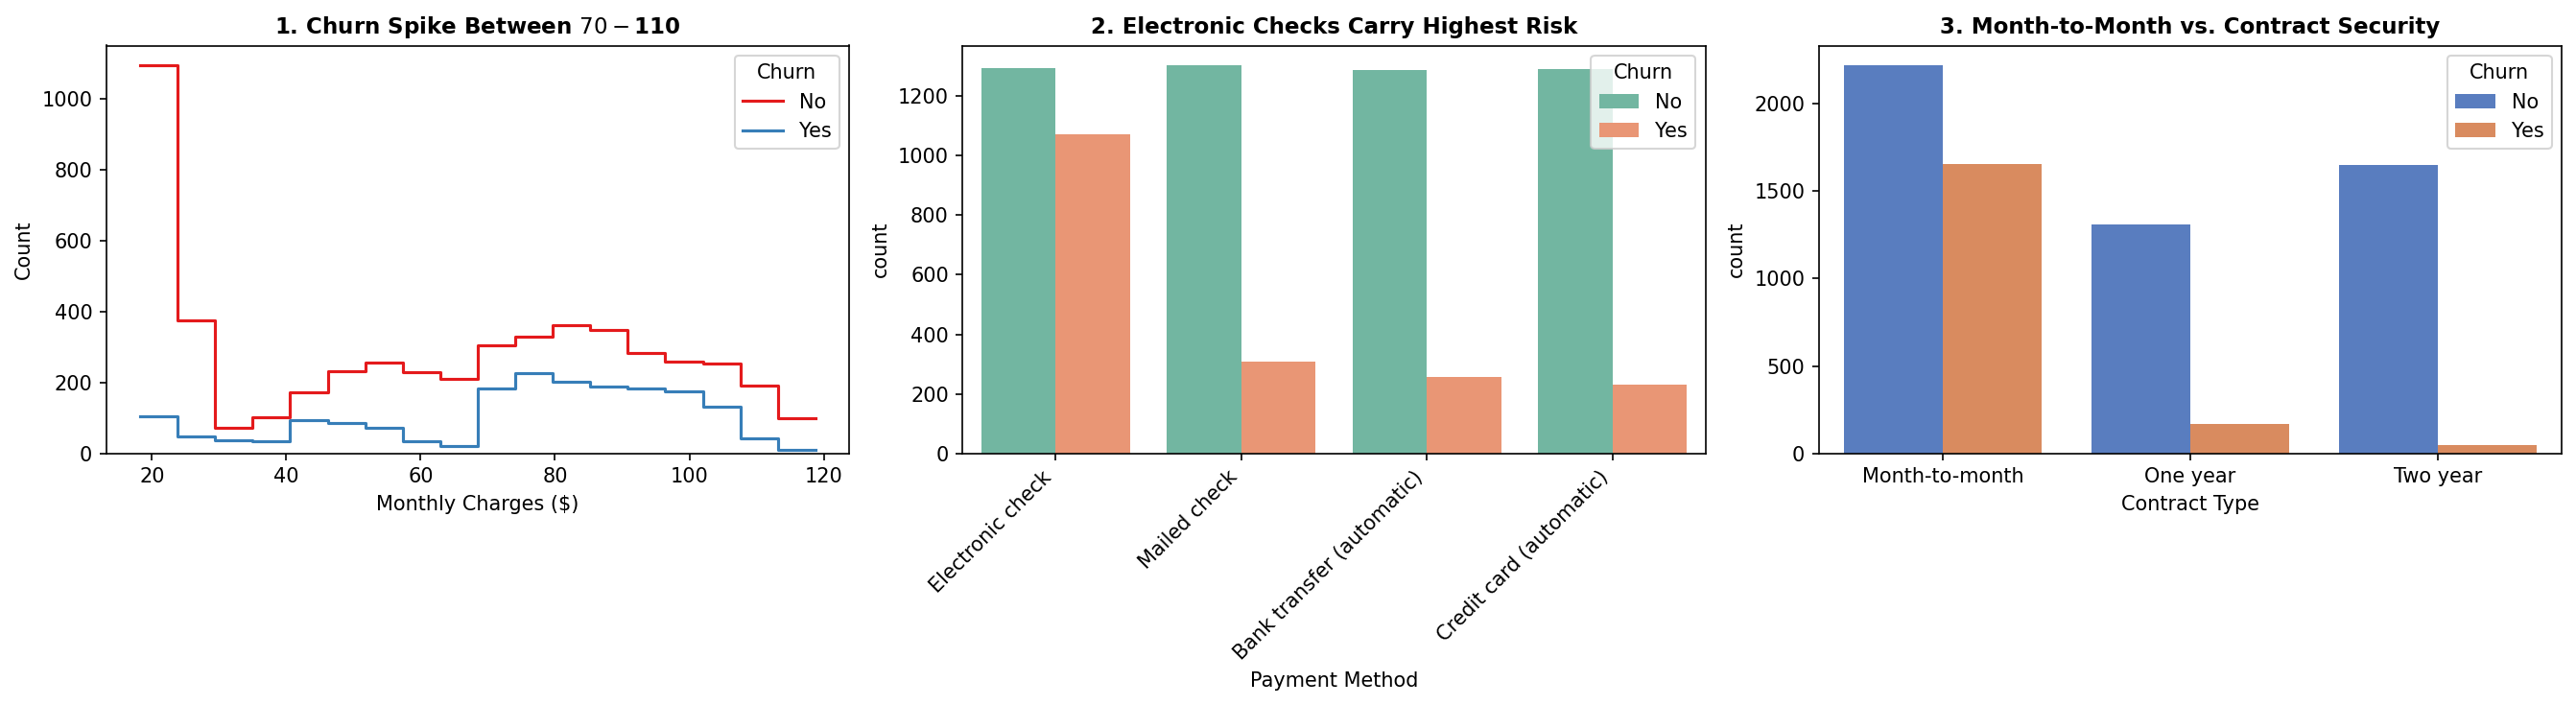

In [55]:
# Initialize a clean 3-column dashboard grid layout
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

# Insight 1: The Price Vulnerability (Using a clean step-line to see overlaps)
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", element="step", fill=False, palette="Set1", ax=ax1)
ax1.set_title("1. Churn Spike Between $70 - $110", fontsize=11, fontweight='bold')
ax1.set_xlabel("Monthly Charges ($)")

# Insight 2: The Payment Method Risk Profile 
sns.countplot(data=df, x="PaymentMethod", hue="Churn", palette="Set2", ax=ax2)
ax2.set_title("2. Electronic Checks Carry Highest Risk", fontsize=11, fontweight='bold')
ax2.set_xlabel("Payment Method")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")

# Insight 3: The Contract Structural Lock
sns.countplot(data=df, x="Contract", hue="Churn", palette="muted", ax=ax3)
ax3.set_title("3. Month-to-Month vs. Contract Security", fontsize=11, fontweight='bold')
ax3.set_xlabel("Contract Type")

# Automatically fix spacing issues between the graphs
plt.tight_layout()


###  Executive Business Insights & Retention Strategy

*   **1. New Customer Billing Baseline Preservation**
    *   *The Discovery*: Forcing the `TotalCharges` schema to numeric unmasked missing data belonging strictly to new customers with a tenure of 0 months. Deleting these fields via `dropna()` would have skewing our sample.
    *   *The Strategy*: Realignment logic was built using `.fillna(df['MonthlyCharges'])`. This successfully preserved our new customer records, setting their initial customer lifetime value baseline correctly.

*   **2. Price Elasticity and Churn Friction Zones**
    *   *The Discovery*: Customer attrition spikes aggressively when monthly billings land in the **$70 to $110 price trap**, exposing significant consumer friction.
    *   *The Strategy*: Establish a proactive threshold warning system. Offer loyalty data bundles to customers as they approach the $70 mark to retain them before they slip into the friction zone.

*   **3. Billing Channel Risk and Auto-Pay Migration**
    *   *The Discovery*: Customers utilizing **Electronic Checks** exhibit a massive, disproportionate churn rate compared to automated banking methods.
    *   *The Strategy*: Trigger an active digital promotion offering a one-time bill credit or discount incentive to successfully migrate Electronic Check users over to Auto-Pay profiles.

*   **4. Contractual Structural Security**
    *   *The Discovery*: Month-to-Month plans hold the highest attrition velocity, while 1-year and 2-year contracts act as a bulletproof retention shield.
    *   *The Strategy*: Re-engineer onboarding packages to emphasize long-term 12 and 24-month contract loops, reducing reliance on high-churn transient accounts.
    
*   **5. Infrastructure Quality Crisis: Fiber Optic Network Leak**
    *   *The Discovery*: Deep segment auditing unmasked a severe vulnerability in our core internet service offerings. Out of the entire corporate churn pool, a massive **~70% of all lost customers (nearly 1,300 users) were utilizing Fiber Optic service.** This represents a destructive 18.5% loss across our entire global subscriber base 
    *   *The Strategy*: Issue an immediate operational red-alert to the engineering and network maintenance teams. Because Fiber Optic issues are the primary driver of corporate attrition, management must audit line stability, hardware connection failures, and local installation quality to stop this massive revenue leak.